In [ ]:
to build a convolutional autoencoder that compresses facial images into a lower- dimentional latent representations and reconstruct them with minimal loss of information

purpose
A convolutional autoencoder in an

SyntaxError: invalid syntax (2862005157.py, line 1)

In [ ]:
import os # math calcul, access file
import shutil # visualization
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf #

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kushsheth/face-vae")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-vae' dataset.
Path to dataset files: /kaggle/input/face-vae


In [ ]:
import os

# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

Files in the dataset directory: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [ ]:
import pandas as pd

# Construct the full path to the CSV file
landmarks_csv_path = os.path.join(path, 'list_landmarks_align_celeba.csv')

# Read the CSV file into a pandas DataFrame
landmarks_df = pd.read_csv(landmarks_csv_path)

# Display the first 5 rows of the DataFrame
display(landmarks_df.head())

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [ ]:
import os
import shutil

source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder, image),
      destination_folder
      )
  print("Copied", len(image), "image")

Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 1

In [ ]:
#Data Preprocessing

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

In [ ]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [ ]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


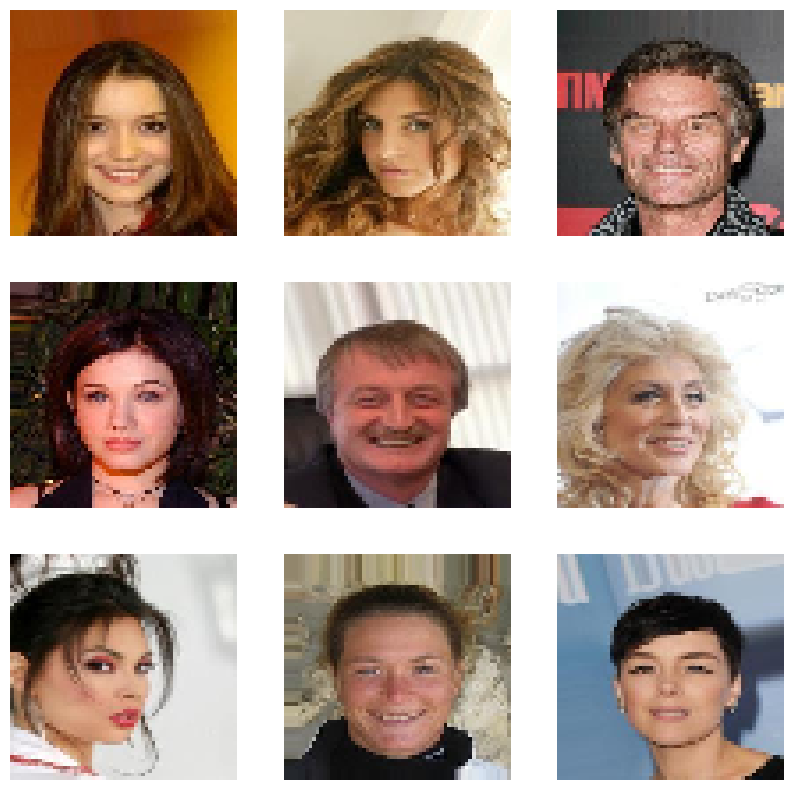

In [ ]:
#display sample image
image,_=next(train_generator)
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(image[i])
  plt.axis('off')
plt.show()

In [ ]:
input_img=Input(shape=(64, 64, 3))
x=Conv2D(32,(3,3),activation="relu",padding="same")(input_img)
encoder=MaxPooling2D((2,2),padding="same")(x)

In [ ]:
#build decoder

x=Conv2D(32,(3,3),activation="relu",padding="same")(encoder)
x=UpSampling2D((2,2))(x)
decoder=Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)


In [ ]:
#model creation
autoencoder=Model(input_img,decoder)

In [ ]:
#comiple model
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [ ]:
#summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,011 (43.01 KB)

 Trainable params: 11,011 (43.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model
history=autoencoder.fit(train_generator,epochs=5,validation_data=train_generator)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.6255 - val_loss: 0.5370
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.5136 - val_loss: 0.5008
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.4967 - val_loss: 0.4939
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.4924 - val_loss: 0.4910
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.4902 - val_loss: 0.4887


/tmp/ipykernel_919/2933850553.py:9: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend('Training','Validation')


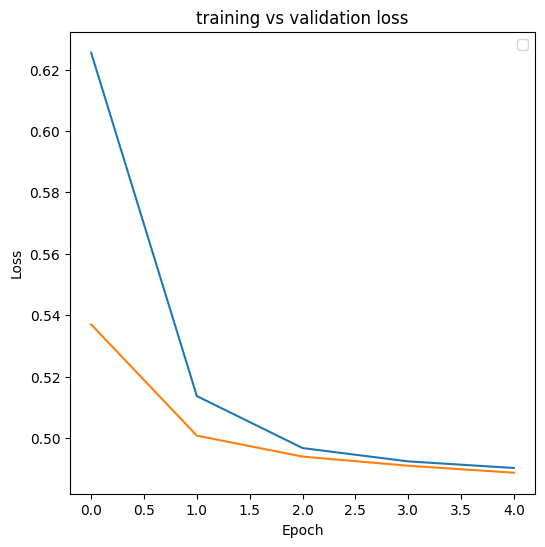

In [ ]:
#plot(
plt.figure(figsize=(6,6))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend('Training','Validation')
plt.show()

In [ ]:
#evalute model
loss=autoencoder.evaluate(train_generator)
print("loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.4887
loss: 0.4886825382709503


In [ ]:
#transcript images
image,_=next(train_generator)
recreatedimages=autoencoder.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step


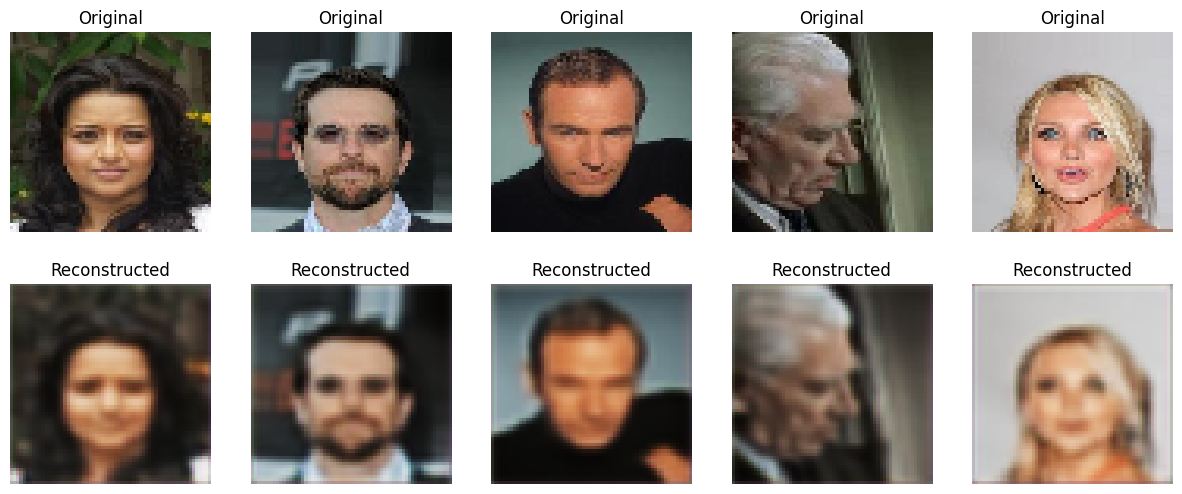

In [ ]:
#display results
n= 5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(image[i])
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(recreatedimages[i])
    plt.title("Reconstructed")
    plt.axis("off")
    plt.imshow(recreatedimages[i])

In [ ]:
hyper parameter: